In [2]:
# prompt: 請讀取Churn_Modelling.csv，並顯示其前五行

import pandas as pd

# Assuming Churn_Modelling.csv is in the current working directory.

df = pd.read_csv('Churn_Modelling.csv')
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [3]:
# prompt: 請將資料中的RowNumber、CustomerId、Surname之欄位數據進行移除 （資料預處理）

import pandas as pd

# Assuming Churn_Modelling.csv is in the current working directory.
df = pd.read_csv('Churn_Modelling.csv')

# Remove specified columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [4]:
# prompt: 請對資料判斷是否有缺失值

# Check for missing values in each column
missing_values = df.isnull().sum()

# Print the number of missing values for each column
print(missing_values)

# Check if there are any missing values in the entire DataFrame
if df.isnull().values.any():
    print("\nThere are missing values in the DataFrame.")
else:
    print("\nThere are no missing values in the DataFrame.")


CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

There are missing values in the DataFrame.


In [5]:
# prompt: 接下來請對 Geography利用眾數補值，Age用中位數來補值，而 HasCrCard、IsActiveMember 則是用衆數來補值 （資料預處理）

import pandas as pd

# Assuming Churn_Modelling.csv is in the current working directory.
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Fill missing values
# Geography: Mode Imputation
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])

# Age: Median Imputation
df['Age'] = df['Age'].fillna(df['Age'].median())

# HasCrCard: Mode Imputation
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])

# IsActiveMember: Mode Imputation
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])


# Verify if missing values are filled
missing_values_after = df.isnull().sum()
print(missing_values_after)

if df.isnull().values.any():
    print("\nThere are still missing values in the DataFrame.")
else:
    print("\nThere are no missing values in the DataFrame.")

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

There are no missing values in the DataFrame.


In [6]:
# prompt: 請將資料中的 Gender 的欄位進行Label Encoding，而 Geography 的欄位則是進行 One-hot Enocoding，以做到類別特徵之轉換（數據類型轉換）

import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np

# Assuming 'df' is your DataFrame and has been preprocessed as shown in your example.

# Label Encoding for 'Gender'
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for 'Geography'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse=False for direct array output
geo_encoded = ohe.fit_transform(df[['Geography']])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out(['Geography']))

# Concatenate the encoded 'Geography' columns with the original DataFrame
df = pd.concat([df, geo_encoded_df], axis=1)

# Remove the original 'Geography' column
df = df.drop(['Geography'], axis=1)

df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42.0,2,0.00,1,1.0,1.0,101348.88,1,1.0,0.0,0.0
1,608,0,41.0,1,83807.86,1,0.0,1.0,112542.58,0,0.0,0.0,1.0
2,502,0,42.0,8,159660.80,3,1.0,0.0,113931.57,1,1.0,0.0,0.0
3,699,0,39.0,1,0.00,2,0.0,0.0,93826.63,0,1.0,0.0,0.0
4,850,0,43.0,2,125510.82,1,1.0,1.0,79084.10,0,0.0,0.0,1.0


In [8]:
# prompt: 請針對以上資料進行隨機森林分類建模，特徵變數：CreditScore	Gender	Age	Tenure	Balance	NumOfProducts	HasCrCard	IsActiveMember	EstimatedSalary Geography_France	Geography_Germany	Geography_Spain
# # ，目標變數：Exited，顯示該模型之參數並進行初始化（先不用進行訓練，但先設定目標變數和特徵變數）

from sklearn.ensemble import RandomForestClassifier

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
        'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier()

# Print model parameters
rf_classifier.get_params()


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [16]:
# prompt: 接下來請以訓練資料及測試資料比率為9：1，並顯示其各部分資料筆數，樹的深度設定爲5，使用決策樹的數量爲10棵，訓練及評估隨機森林模型

import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset (assuming 'Churn_Modelling.csv' is in the current directory)
df = pd.read_csv('Churn_Modelling.csv')

# Preprocessing steps (same as before)
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Fill missing values (if any)
# Geography: Mode Imputation
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])
# Age: Median Imputation
df['Age'] = df['Age'].fillna(df['Age'].median())
# HasCrCard: Mode Imputation
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])
# IsActiveMember: Mode Imputation
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])


# Label Encoding for 'Gender'
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for 'Geography'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
geo_encoded = ohe.fit_transform(df[['Geography']])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out(['Geography']))
df = pd.concat([df, geo_encoded_df], axis=1)
df = df.drop(['Geography'], axis=1)


# Define features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data into training and testing sets (9:1 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Print the number of samples in each set
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42) # Set parameters here
rf_classifier.fit(X_train, y_train)


# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Training data shape: (9001, 12)
Testing data shape: (1001, 12)
Accuracy: 0.8621378621378621
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       803
           1       0.79      0.41      0.54       198

    accuracy                           0.86      1001
   macro avg       0.83      0.69      0.73      1001
weighted avg       0.85      0.86      0.84      1001



In [10]:
# prompt: 接下來請改以訓練資料及測試資料比率為8：2，並顯示其各部分資料筆數，樹的深度設定爲5，使用決策樹的數量爲10棵，訓練及評估隨機森林模型

import pandas as pd
# Load the dataset (assuming 'Churn_Modelling.csv' is in the current directory)
df = pd.read_csv('Churn_Modelling.csv')

# Preprocessing steps (same as before)
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Fill missing values (if any)
# Geography: Mode Imputation
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])
# Age: Median Imputation
df['Age'] = df['Age'].fillna(df['Age'].median())
# HasCrCard: Mode Imputation
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])
# IsActiveMember: Mode Imputation
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])


# Label Encoding for 'Gender'
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for 'Geography'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
geo_encoded = ohe.fit_transform(df[['Geography']])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out(['Geography']))
df = pd.concat([df, geo_encoded_df], axis=1)
df = df.drop(['Geography'], axis=1)


# Define features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data into training and testing sets (8:2 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the number of samples in each set
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42) # Set parameters here
rf_classifier.fit(X_train, y_train)


# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Training data shape: (8001, 12)
Testing data shape: (2001, 12)
Accuracy: 0.8600699650174912
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1599
           1       0.81      0.40      0.53       402

    accuracy                           0.86      2001
   macro avg       0.84      0.69      0.73      2001
weighted avg       0.85      0.86      0.84      2001



In [13]:
# prompt: 接下來請改以訓練資料及測試資料比率為7：3，並顯示其各部分資料筆數，樹的深度設定爲5，使用決策樹的數量爲10棵，訓練及評估隨機森林模型

import pandas as pd
# Load the dataset (assuming 'Churn_Modelling.csv' is in the current directory)
df = pd.read_csv('Churn_Modelling.csv')

# Preprocessing steps (same as before)
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Fill missing values (if any)
# Geography: Mode Imputation
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])
# Age: Median Imputation
df['Age'] = df['Age'].fillna(df['Age'].median())
# HasCrCard: Mode Imputation
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])
# IsActiveMember: Mode Imputation
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])


# Label Encoding for 'Gender'
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for 'Geography'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
geo_encoded = ohe.fit_transform(df[['Geography']])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out(['Geography']))
df = pd.concat([df, geo_encoded_df], axis=1)
df = df.drop(['Geography'], axis=1)


# Define features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data into training and testing sets (7:3 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the number of samples in each set
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42) # Set parameters here
rf_classifier.fit(X_train, y_train)


# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Training data shape: (7001, 12)
Testing data shape: (3001, 12)
Accuracy: 0.8563812062645785
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2401
           1       0.81      0.37      0.51       600

    accuracy                           0.86      3001
   macro avg       0.83      0.67      0.71      3001
weighted avg       0.85      0.86      0.83      3001



In [14]:
# prompt: 接下來請改以訓練資料及測試資料比率為6：4，並顯示其各部分資料筆數，樹的深度設定爲5，使用決策樹的數量爲10棵，訓練及評估隨機森林模型

import pandas as pd
# Load the dataset (assuming 'Churn_Modelling.csv' is in the current directory)
df = pd.read_csv('Churn_Modelling.csv')

# Preprocessing steps (same as before)
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Fill missing values (if any)
# Geography: Mode Imputation
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])
# Age: Median Imputation
df['Age'] = df['Age'].fillna(df['Age'].median())
# HasCrCard: Mode Imputation
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])
# IsActiveMember: Mode Imputation
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])


# Label Encoding for 'Gender'
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for 'Geography'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
geo_encoded = ohe.fit_transform(df[['Geography']])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out(['Geography']))
df = pd.concat([df, geo_encoded_df], axis=1)
df = df.drop(['Geography'], axis=1)


# Define features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data into training and testing sets (6:4 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Print the number of samples in each set
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Initialize and train the Random Forest Classifier with specified parameters
rf_classifier = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Training data shape: (6001, 12)
Testing data shape: (4001, 12)
Accuracy: 0.8520369907523119
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      3196
           1       0.83      0.33      0.48       805

    accuracy                           0.85      4001
   macro avg       0.84      0.66      0.69      4001
weighted avg       0.85      0.85      0.83      4001



Confusion Matrix:
[[781  22]
 [116  82]]


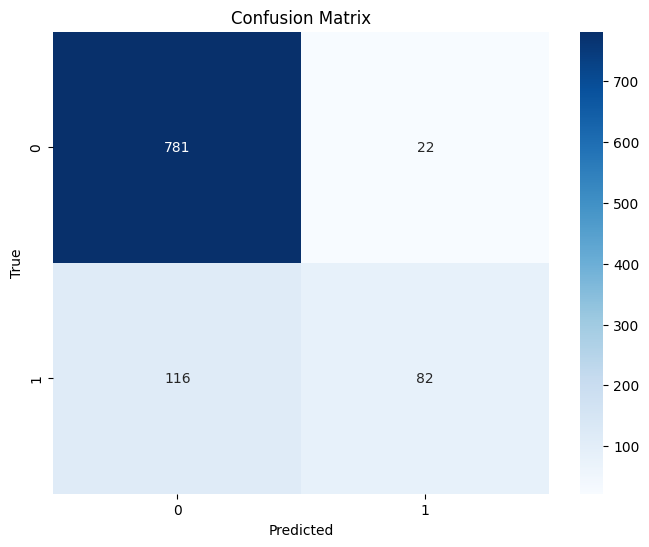


Accuracy: 0.8621378621378621

Precision: 0.7884615384615384

Recall: 0.41414141414141414

F1 Score: 0.543046357615894


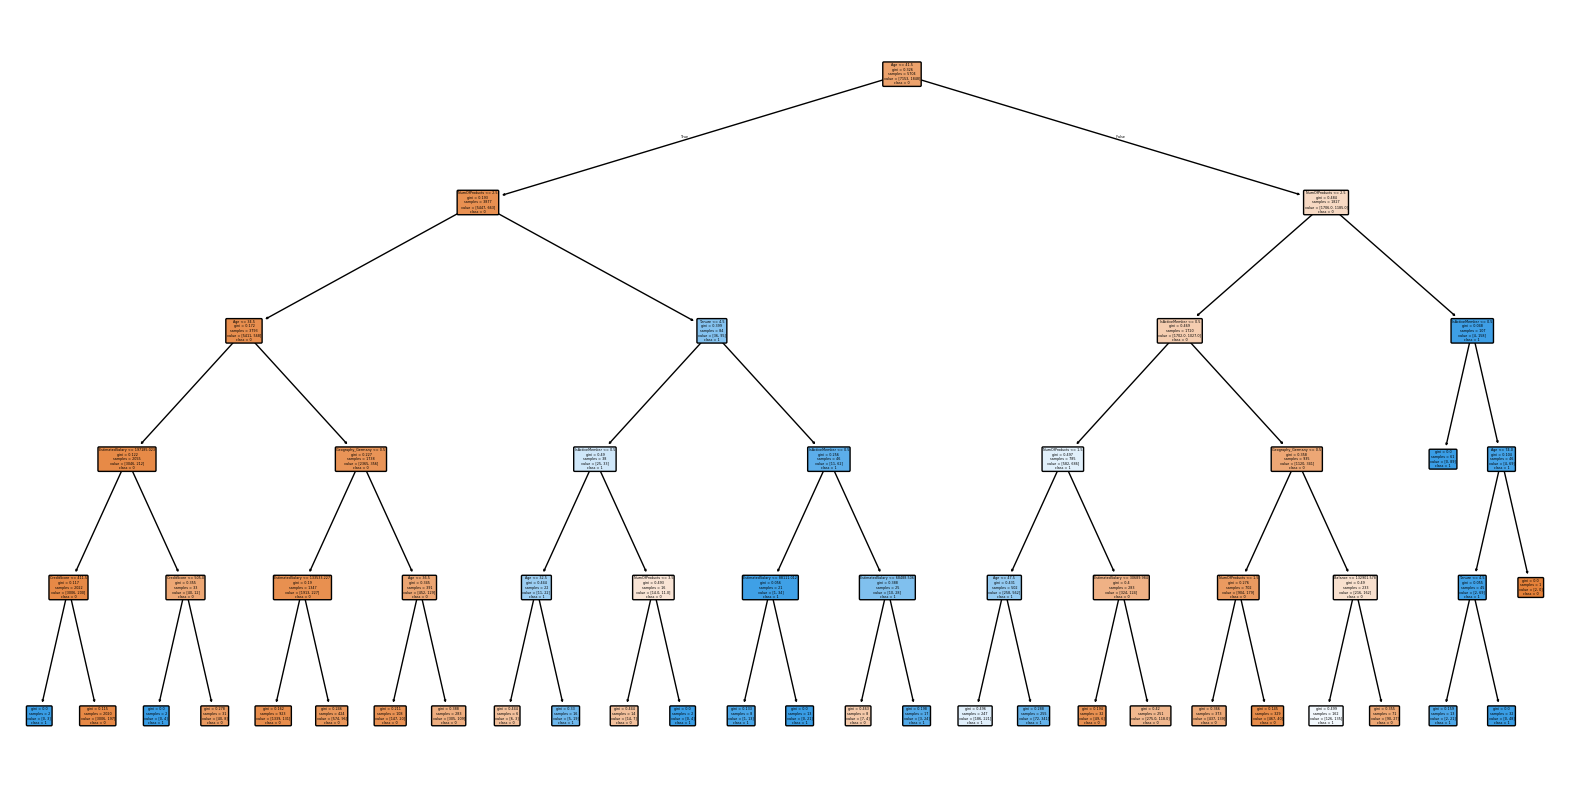

In [15]:
# prompt: 接下來請以訓練資料及測試資料比率為9：1來訓練的模型爲基準，來進行預測結果的評估（混淆矩陣、accuracy、precision、recall、f1 score、畫出樹狀圖形等）

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ... (Your existing code for data loading and preprocessing) ...


# Split data into training and testing sets (9:1 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Initialize and train the Random Forest Classifier (use the best parameters you found)
rf_classifier = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42) #Example parameters, replace with your best ones
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nPrecision:", precision_score(y_test, y_pred))
print("\nRecall:", recall_score(y_test, y_pred))
print("\nF1 Score:", f1_score(y_test, y_pred))


#Plot a single decision tree from the random forest (for visualization purposes)
plt.figure(figsize=(20,10))
plot_tree(rf_classifier.estimators_[0], feature_names=X.columns, class_names=['0','1'], filled=True, rounded=True)
plt.show()



訓練資料筆數: 9001
測試資料筆數: 1001

隨機森林模型參數：

--- Model Evaluation ---
Confusion Matrix:
 [[781  22]
 [116  82]]


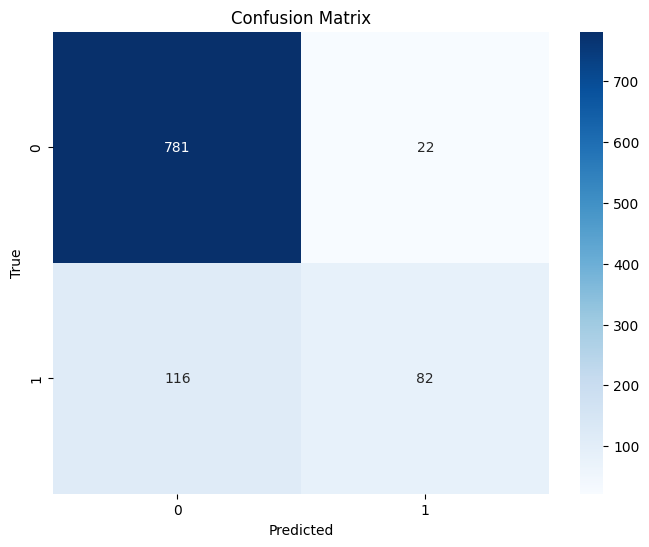

Accuracy: 0.8621378621378621
Precision: 0.7884615384615384
Recall: 0.41414141414141414
F1 Score: 0.543046357615894

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92       803
           1       0.79      0.41      0.54       198

    accuracy                           0.86      1001
   macro avg       0.83      0.69      0.73      1001
weighted avg       0.85      0.86      0.84      1001



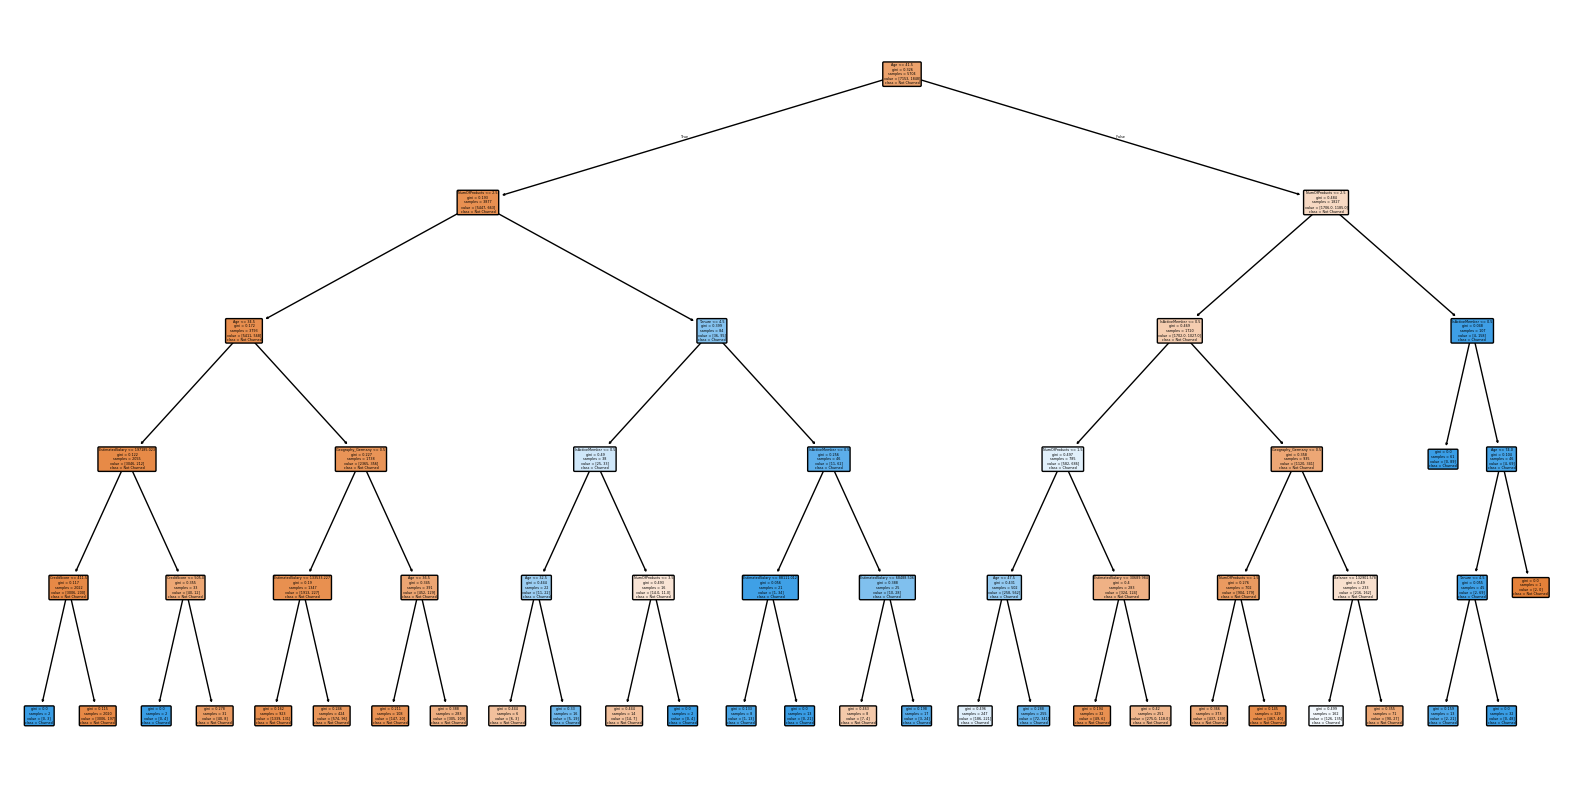

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)
from sklearn.tree import plot_tree

# 1. 讀取資料
df = pd.read_csv('Churn_Modelling.csv')

# 2. 移除無用欄位
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

# 3. 缺失值處理
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])

# 4. 類別欄位編碼
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
geo_encoded = ohe.fit_transform(df[['Geography']])
geo_encoded_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out(['Geography']))
df = pd.concat([df.drop('Geography', axis=1), geo_encoded_df], axis=1)

# 5. 定義特徵與目標變數
X = df.drop('Exited', axis=1)
y = df['Exited']

# 6. 分割資料集（訓練：測試 = 9:1）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(f"\n訓練資料筆數: {X_train.shape[0]}")
print(f"測試資料筆數: {X_test.shape[0]}")

# 7. 隨機森林初始化與訓練
rf_classifier = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42)
print("\n隨機森林模型參數：")
rf_classifier.get_params()

rf_classifier.fit(X_train, y_train)

# 8. 模型預測
y_pred = rf_classifier.predict(X_test)

# 9. 評估模型
print("\n--- Model Evaluation ---")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 10. 繪製隨機森林中的一棵樹
plt.figure(figsize=(20, 10))
plot_tree(rf_classifier.estimators_[0], feature_names=X.columns, class_names=['Not Churned', 'Churned'], filled=True, rounded=True)
plt.show()
